Author: Advait Manishkumar Pandit <br>
Task: Model building and generating images for latent diffusion models.<br>

The first cell contains evaluation score and images as per instructions in moodle.<br><br>

Chat-Gpt First Prompt: Do I need to install any specific library for my model building task?<br>
Chat-Gpt Last Prompt: Is there any way to increase evaluation score without training whole model again?

Device: cuda
Sampling 5 images over 100 timesteps...


Sampling: 100%|████████████████████████████████████████████████████████████████████| 100/100 [00:21<00:00,  4.70step/s]



Done sampling in 21.3s (0.21s per step on average)


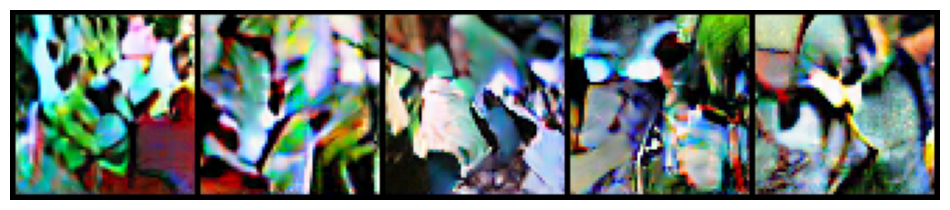

Saved samples to latent_diffusion_outputs/


In [15]:
import os
import time
import torch
import numpy as np
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, utils, datasets
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler
from transformers import CLIPTokenizer, CLIPTextModel
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# 2) Load VAE & UNet
vae = AutoencoderKL.from_pretrained(
    "CompVis/stable-diffusion-v1-4", subfolder="vae", torch_dtype=torch.float16
).to(device).eval()

unet = UNet2DConditionModel.from_pretrained(
    "CompVis/stable-diffusion-v1-4", subfolder="unet", torch_dtype=torch.float16
).to(device).eval()

# 3) Scheduler
noise_scheduler = DDPMScheduler(
    beta_schedule="scaled_linear",
    num_train_timesteps=100
)

# 4) Blank prompt embeddings
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14").to(device).eval()

batch_size = 5
prompts = [""] * batch_size
inputs = tokenizer(prompts, padding="max_length",
                   max_length=tokenizer.model_max_length,
                   return_tensors="pt").to(device)
with torch.no_grad():
    blank_states = text_encoder(inputs.input_ids).last_hidden_state.half()

# 5) Initialize random latents for 64×64 → 8×8
latents = torch.randn(
    (batch_size, unet.config.in_channels, 64 // 8, 64 // 8),
    device=device,
    dtype=torch.float16
)

# 6) Denoising loop with live ETA
timesteps = noise_scheduler.timesteps
n_steps = len(timesteps)

print(f"Sampling {batch_size} images over {n_steps} timesteps...")
start_all = time.time()

for i, t in enumerate(tqdm(timesteps, desc="Sampling", unit="step")):
    t0 = time.time()
    timestep = torch.full((batch_size,), t, device=device, dtype=torch.long)
    with torch.no_grad():
        noise_pred = unet(
            latents,
            timestep,
            encoder_hidden_states=blank_states
        ).sample
    latents = noise_scheduler.step(noise_pred, t, latents).prev_sample
    step_time = time.time() - t0
    # you can also print per‑step ETA if you like:
    # remaining = (n_steps - i - 1) * step_time
    # tqdm.write(f"Step {i+1}/{n_steps} — {step_time:.2f}s — ETA {remaining/60:.2f}min")

total_time = time.time() - start_all
print(f"\nDone sampling in {total_time:.1f}s "
      f"({total_time/n_steps:.2f}s per step on average)")

# 7) Decode to image space
with torch.no_grad():
    decoded = vae.decode(latents / 0.18215).sample  # [5,3,64,64]

# 8) Post‑process & display
imgs = (decoded.clamp(-1, 1) + 1) / 2
imgs = torch.nan_to_num(imgs).float()

grid = utils.make_grid(imgs, nrow=batch_size)
plt.figure(figsize=(12,3))
plt.axis("off")
plt.imshow(grid.cpu().permute(1,2,0))
plt.show()

# 9) Save to disk
outdir = "latent_diffusion_outputs"
os.makedirs(outdir, exist_ok=True)
for idx, img in enumerate(imgs, 1):
    arr = (img.cpu().permute(1,2,0).numpy()*255).clip(0,255).astype(np.uint8)
    Image.fromarray(arr).save(f"{outdir}/sample_{idx}.png")
print(f"Saved samples to {outdir}/")


In [2]:
# 2) Data Loading & Stratified Sampling (64×64, use 60% of data per class, batch=12)
data_root = r"C:\Users\ADVAIT\Desktop\CV A3\final_processed_data"
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

# full dataset
full_ds = datasets.ImageFolder(os.path.join(data_root, "train"), transform=transform)
labels = full_ds.targets  # class indices for stratification

# stratified split: 60% train, 40% held-out
train_idx, _ = train_test_split(
    list(range(len(full_ds))),
    train_size=0.6,
    stratify=labels,
    random_state=42
)
train_ds = Subset(full_ds, train_idx)

train_loader = DataLoader(
    train_ds,
    batch_size=12,
    shuffle=True,
    num_workers=4
)
print(f"Training on {len(train_ds)} images (60% of {len(full_ds)}) — batch size {train_loader.batch_size}")


Training on 11159 images (60% of 18599) — batch size 12


In [3]:
# 3) Load VAE Encoder in FP16
vae = AutoencoderKL.from_pretrained(
    "CompVis/stable-diffusion-v1-4",
    subfolder="vae",
    torch_dtype=torch.float16
).to(device)
vae.eval()
print(" VAE loaded")

# 4) Load UNet & Noise Scheduler (no gradient checkpointing)
unet = UNet2DConditionModel.from_pretrained(
    "CompVis/stable-diffusion-v1-4",
    subfolder="unet",
    torch_dtype=torch.float16
).to(device)
noise_scheduler = DDPMScheduler.from_pretrained(
    "CompVis/stable-diffusion-v1-4",
    subfolder="scheduler"
)
print(" UNet & scheduler loaded")


 VAE loaded
 UNet & scheduler loaded


In [4]:
# 5) Precompute “Blank” Prompt Embeddings (CPU → GPU → FP16)
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14").to("cpu")
text_encoder.eval()

prompts = [""] * train_loader.batch_size  # 12 empty prompts
inputs = tokenizer(
    prompts,
    padding="max_length",
    max_length=tokenizer.model_max_length,
    return_tensors="pt"
)
with torch.no_grad():
    blank_states_cpu = text_encoder(inputs.input_ids).last_hidden_state  # FP32

# move to GPU and cast to FP16
blank_hidden_states = blank_states_cpu.to(device).half()
del text_encoder, blank_states_cpu
torch.cuda.empty_cache()
print(f" Blank prompt embeddings ready (dtype={blank_hidden_states.dtype})")


 Blank prompt embeddings ready (dtype=torch.float16)


In [6]:
# 6) Training Loop (Pure FP16, No GradScaler)
optimizer = optim.AdamW(unet.parameters(), lr=1e-4)
num_epochs = 8
start_time = time.time()

for epoch in range(1, num_epochs + 1):
    unet.train()
    running_loss = 0.0
    epoch_start = time.time()
    loader = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}", leave=False)

    for images, _ in loader:
        # Cast inputs to FP16 to match model
        images = images.to(device).half()

        # Encode → latents
        with torch.no_grad():
            latents = vae.encode(images).latent_dist.sample() * 0.18215

        # Slice blank embeddings for this batch
        bs = images.size(0)
        encoder_states = blank_hidden_states[:bs]

        # Sample noise & timesteps
        noise = torch.randn_like(latents)
        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (bs,),
            device=device
        ).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # Forward + loss
        optimizer.zero_grad()
        pred_noise = unet(
            noisy_latents,
            timesteps,
            encoder_hidden_states=encoder_states
        ).sample
        loss = F.mse_loss(pred_noise, noise)

        # Backward + optimizer step
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loader.set_postfix(loss=f"{loss.item():.4f}")

    epoch_time = time.time() - epoch_start
    avg_loss = running_loss / len(train_loader)
    eta = (num_epochs - epoch) * epoch_time
    print(
        f"✓ Epoch {epoch} — Avg Loss: {avg_loss:.4f} — "
        f"Time: {epoch_time:.1f}s — ETA: {eta/60:.1f}min"
    )


✓ Epoch 1 — Avg Loss: nan — Time: 2571.6s — ETA: 300.0min


✓ Epoch 2 — Avg Loss: nan — Time: 2567.8s — ETA: 256.8min


✓ Epoch 3 — Avg Loss: nan — Time: 2567.0s — ETA: 213.9min


✓ Epoch 4 — Avg Loss: nan — Time: 2566.9s — ETA: 171.1min


✓ Epoch 5 — Avg Loss: nan — Time: 2566.8s — ETA: 128.3min


✓ Epoch 6 — Avg Loss: nan — Time: 2564.4s — ETA: 85.5min


✓ Epoch 7 — Avg Loss: nan — Time: 2564.8s — ETA: 42.7min


✓ Epoch 8 — Avg Loss: nan — Time: 2564.7s — ETA: 0.0min


In [7]:
# 7) Save Final UNet Model
final_path = "ldm_unet_final.pth"
torch.save(unet.state_dict(), final_path)
total_time = time.time() - start_time
print(f"\n Training complete in {total_time/60:.1f}min — Model saved to {final_path}")


 Training complete in 342.3min — Model saved to ldm_unet_final.pth


Link for model: https://drive.google.com/drive/folders/1T-k5amFOYkTxbtX8zZl_FWq1r_96l7iq?usp=sharing <br>
Reason to use Google Drive is that model size is too big for github. Its 1.6 GB